In [22]:
import os
import numpy as np
import pandas as pd
from scipy import sparse
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from typing import Dict, Tuple

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (
    f1_score, hamming_loss, accuracy_score,
    average_precision_score, precision_recall_curve
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Versions:")
import sklearn, sys
print("  Python:", sys.version.split()[0])
print("  scikit-learn:", sklearn.__version__)


Versions:
  Python: 3.14.4
  scikit-learn: 1.8.0


In [23]:
# ── 1. Data loading ───────────────────────────────────────────────────────────

def load_yeast_arff(data_dir: str = "./data/yeast"):
    from skmultilearn.dataset import load_from_arff
    print(f"Trying local ARFF in {data_dir}…")
    tr = os.path.join(data_dir, "yeast-train.arff")
    te = os.path.join(data_dir, "yeast-test.arff")
    if not (os.path.exists(tr) and os.path.exists(te)):
        raise FileNotFoundError(f"Put yeast-train.arff & yeast-test.arff in {data_dir}.")
    def _load(p):
        X, y, fn, ln = load_from_arff(p, label_count=14 , return_attribute_definitions=True)
        to_dense = lambda a: a.toarray() if sparse.issparse(a) else a
        return to_dense(X).astype(np.float32), to_dense(y).astype(np.float32), fn, ln
    X_tr, y_tr, fn, ln = _load(tr)
    X_te, y_te, _,  _  = _load(te)
    print(f"ARFF: train {X_tr.shape}, test {X_te.shape}")
    return X_tr, y_tr, X_te, y_te, fn, ln


use_canonical = True
X_tr, Y_tr, X_te, Y_te, feat_names, label_names = load_yeast_arff("/work/gr-fe/bryan/data/YEAST/yeast")

X_tr, X_val, Y_tr, Y_val = train_test_split(
    X_tr, Y_tr, test_size=0.2, random_state=RANDOM_STATE)

print("Shapes:")
print("  Train:", X_tr.shape, Y_tr.shape)
print("  Val:  ", X_val.shape, Y_val.shape)
print("  Test: ", X_te.shape,  Y_te.shape)

# Sanity checks
def label_stats(Y):
    return {
        "cardinality": float(Y.sum(axis=1).mean()),
        "density": float(Y.sum(axis=1).mean() / Y.shape[1]),
        "positives": Y.sum(axis=0).astype(int)
    }

print("Train stats:", label_stats(Y_tr))
print("Val stats:  ", label_stats(Y_val))
print("Test stats: ", label_stats(Y_te))

Trying local ARFF in /work/gr-fe/bryan/data/YEAST/yeast…
ARFF: train (1500, 103), test (917, 103)
Shapes:
  Train: (1200, 103) (1200, 14)
  Val:   (300, 103) (300, 14)
  Test:  (917, 103) (917, 14)
Train stats: {'cardinality': 4.196666717529297, 'density': 0.29976192116737366, 'positives': array([372, 517, 491, 427, 346, 290, 199, 228,  78, 126, 155, 899, 890,
        18])}
Val stats:   {'cardinality': 4.353333473205566, 'density': 0.31095239520072937, 'positives': array([104, 128, 107, 105,  95,  88,  62,  61,  20,  35,  43, 229, 226,
         3])}
Test stats:  {'cardinality': 4.251908302307129, 'density': 0.3037077486515045, 'positives': array([286, 393, 385, 330, 281, 219, 167, 191,  80,  92,  91, 688, 683,
        13])}


In [24]:
def evaluate_from_scores(y_true: np.ndarray, y_scores: np.ndarray, thr=0.5) -> Dict[str, float]:
    y_pred = (y_scores >= thr).astype(int)
    return {
        "F1-micro":    f1_score(y_true, y_pred, average="micro", zero_division=0),
        "F1-macro":    f1_score(y_true, y_pred, average="macro", zero_division=0),
        "mAP-micro":   average_precision_score(y_true, y_scores, average="micro"),
        "mAP-macro":   average_precision_score(y_true, y_scores, average="macro"),
        "HammingLoss": hamming_loss(y_true, y_pred),
        "SubsetAcc":   accuracy_score(y_true, y_pred),
        "PredCard":    float(y_pred.sum(axis=1).mean()),
    }

def fit_perlabel_thresholds(y_true: np.ndarray, y_scores: np.ndarray, default=0.5) -> np.ndarray:
    t = np.full(y_true.shape[1], default, dtype=np.float32)
    for j in range(y_true.shape[1]):
        yj = y_true[:, j]
        if yj.sum() == 0:
            continue
        p, r, thr = precision_recall_curve(yj, y_scores[:, j])
        f1 = 2 * p[:-1] * r[:-1] / (p[:-1] + r[:-1] + 1e-12)
        if np.any(np.isfinite(f1)):
            t[j] = thr[np.nanargmax(f1)]
    return t

def find_global_threshold(y_true: np.ndarray, y_scores: np.ndarray,
                          t_min=0.05, t_max=0.8, steps=60, metric="f1_micro") -> Tuple[float, Dict[str,float]]:
    best_t, best_metrics = 0.5, None
    best_val = -np.inf
    grid = np.linspace(t_min, t_max, steps)
    for t in grid:
        m = evaluate_from_scores(y_true, y_scores, thr=t)
        val = m["F1-micro"] if metric == "f1_micro" else m["mAP-micro"]
        if val > best_val:
            best_val, best_t, best_metrics = val, float(t), m
    return best_t, best_metrics

def print_metrics(title: str, m: Dict[str, float]):
    print(title)
    for k in ["F1-micro","F1-macro","mAP-micro","mAP-macro","HammingLoss","SubsetAcc","PredCard"]:
        if k in m:
            print(f"  {k:>11}: {m[k]:.4f}")


In [25]:
# Model: One-vs-Rest Logistic Regression with StandardScaler
def build_model(C=1.0, max_iter=2000, class_weight="balanced"):
    base = LogisticRegression(
        solver="liblinear", penalty="l2", C=C, max_iter=max_iter,
        class_weight=class_weight, random_state=RANDOM_STATE
    )
    return make_pipeline(StandardScaler(with_mean=True, with_std=True),
                         OneVsRestClassifier(base, n_jobs=-1))

# Small grid over C using validation micro-F1 at threshold 0.5
C_grid = [0.1, 0.5, 1.0, 2.0, 5.0]
val_scores = []

for C in C_grid:
    clf = build_model(C=C)
    clf.fit(X_tr, Y_tr)
    # Validation probabilities
    Y_val_scores = clf.predict_proba(X_val)
    m = evaluate_from_scores(Y_val, Y_val_scores, thr=0.5)
    val_scores.append((C, m["F1-micro"], m["mAP-micro"]))
    print_metrics(f"C={C} — Val metrics @thr=0.5", m)

# Pick best C by val micro-F1 (you could switch to mAP if you prefer)
best_C = max(val_scores, key=lambda x: x[1])[0]
print("\nBest C by val micro-F1:", best_C)


C=0.1 — Val metrics @thr=0.5
     F1-micro: 0.5597
     F1-macro: 0.4680
    mAP-micro: 0.5298
    mAP-macro: 0.4702
  HammingLoss: 0.3202
    SubsetAcc: 0.0467
     PredCard: 5.8300
C=0.5 — Val metrics @thr=0.5
     F1-micro: 0.5589
     F1-macro: 0.4660
    mAP-micro: 0.5185
    mAP-macro: 0.4662
  HammingLoss: 0.3190
    SubsetAcc: 0.0500
     PredCard: 5.7733
C=1.0 — Val metrics @thr=0.5
     F1-micro: 0.5612
     F1-macro: 0.4676
    mAP-micro: 0.5160
    mAP-macro: 0.4657
  HammingLoss: 0.3169
    SubsetAcc: 0.0500
     PredCard: 5.7567
C=2.0 — Val metrics @thr=0.5
     F1-micro: 0.5622
     F1-macro: 0.4681
    mAP-micro: 0.5139
    mAP-macro: 0.4648
  HammingLoss: 0.3160
    SubsetAcc: 0.0500
     PredCard: 5.7500
C=5.0 — Val metrics @thr=0.5
     F1-micro: 0.5613
     F1-macro: 0.4668
    mAP-micro: 0.5115
    mAP-macro: 0.4644
  HammingLoss: 0.3160
    SubsetAcc: 0.0500
     PredCard: 5.7300

Best C by val micro-F1: 2.0


In [26]:
# Refit best model on the same train split to produce scores for threshold tuning
best_clf = build_model(C=best_C)
best_clf.fit(X_tr, Y_tr)
Y_val_scores = best_clf.predict_proba(X_val)

# 6a) Global threshold tuned for micro-F1
t_global, m_val_global = find_global_threshold(Y_val, Y_val_scores, metric="f1_micro")
print_metrics(f"\nVal metrics — tuned global threshold t={t_global:.3f}", m_val_global)

# 6b) Per-label thresholds tuned for F1
t_perlabel = fit_perlabel_thresholds(Y_val, Y_val_scores, default=0.5)
Y_val_pred_pl = (Y_val_scores >= t_perlabel).astype(int)
m_val_pl = {
    "F1-micro":  f1_score(Y_val, Y_val_pred_pl, average="micro", zero_division=0),
    "F1-macro":  f1_score(Y_val, Y_val_pred_pl, average="macro", zero_division=0),
    "mAP-micro": average_precision_score(Y_val, Y_val_scores, average="micro"),
    "mAP-macro": average_precision_score(Y_val, Y_val_scores, average="macro"),
    "HammingLoss": hamming_loss(Y_val, Y_val_pred_pl),
    "SubsetAcc":   accuracy_score(Y_val, Y_val_pred_pl),
    "PredCard":    float(Y_val_pred_pl.sum(axis=1).mean()),
}
print_metrics("Val metrics — tuned per-label thresholds", m_val_pl)

# Decide which thresholding strategy to use for final test evaluation
use_perlabel = m_val_pl["F1-micro"] >= m_val_global["F1-micro"]
chosen = "per-label" if use_perlabel else f"global (t={t_global:.3f})"
print("\nChosen thresholding for test:", chosen)



Val metrics — tuned global threshold t=0.469
     F1-micro: 0.5655
     F1-macro: 0.4718
    mAP-micro: 0.5139
    mAP-macro: 0.4648
  HammingLoss: 0.3271
    SubsetAcc: 0.0467
     PredCard: 6.1867
Val metrics — tuned per-label thresholds
     F1-micro: 0.5919
     F1-macro: 0.5022
    mAP-micro: 0.5139
    mAP-macro: 0.4648
  HammingLoss: 0.3369
    SubsetAcc: 0.0100
     PredCard: 7.2033

Chosen thresholding for test: per-label


In [27]:
# Refit best model on the same train split to produce scores for threshold tuning
best_clf = build_model(C=best_C)
best_clf.fit(X_tr, Y_tr)
Y_val_scores = best_clf.predict_proba(X_val)

# 6a) Global threshold tuned for micro-F1
t_global, m_val_global = find_global_threshold(Y_val, Y_val_scores, metric="f1_micro")
print_metrics(f"\nVal metrics — tuned global threshold t={t_global:.3f}", m_val_global)

# 6b) Per-label thresholds tuned for F1
t_perlabel = fit_perlabel_thresholds(Y_val, Y_val_scores, default=0.5)
Y_val_pred_pl = (Y_val_scores >= t_perlabel).astype(int)
m_val_pl = {
    "F1-micro":  f1_score(Y_val, Y_val_pred_pl, average="micro", zero_division=0),
    "F1-macro":  f1_score(Y_val, Y_val_pred_pl, average="macro", zero_division=0),
    "mAP-micro": average_precision_score(Y_val, Y_val_scores, average="micro"),
    "mAP-macro": average_precision_score(Y_val, Y_val_scores, average="macro"),
    "HammingLoss": hamming_loss(Y_val, Y_val_pred_pl),
    "SubsetAcc":   accuracy_score(Y_val, Y_val_pred_pl),
    "PredCard":    float(Y_val_pred_pl.sum(axis=1).mean()),
}
print_metrics("Val metrics — tuned per-label thresholds", m_val_pl)

# Decide which thresholding strategy to use for final test evaluation
use_perlabel = m_val_pl["F1-micro"] >= m_val_global["F1-micro"]
chosen = "per-label" if use_perlabel else f"global (t={t_global:.3f})"
print("\nChosen thresholding for test:", chosen)



Val metrics — tuned global threshold t=0.469
     F1-micro: 0.5655
     F1-macro: 0.4718
    mAP-micro: 0.5139
    mAP-macro: 0.4648
  HammingLoss: 0.3271
    SubsetAcc: 0.0467
     PredCard: 6.1867
Val metrics — tuned per-label thresholds
     F1-micro: 0.5919
     F1-macro: 0.5022
    mAP-micro: 0.5139
    mAP-macro: 0.4648
  HammingLoss: 0.3369
    SubsetAcc: 0.0100
     PredCard: 7.2033

Chosen thresholding for test: per-label


In [28]:
# Final refit on train+val with best C
X_tr_full = np.vstack([X_tr, X_val])
Y_tr_full = np.vstack([Y_tr, Y_val])

final_clf = build_model(C=best_C)
final_clf.fit(X_tr_full, Y_tr_full)

# Test probabilities
Y_te_scores = final_clf.predict_proba(X_te)

# Use chosen thresholds
if use_perlabel:
    thr_for_test = t_perlabel
    m_test = evaluate_from_scores(Y_te, Y_te_scores, thr=thr_for_test)
else:
    thr_for_test = t_global
    m_test = evaluate_from_scores(Y_te, Y_te_scores, thr=thr_for_test)

print_metrics("\nTest metrics — chosen thresholding", m_test)

# Also show t=0.5 for reference
m_test_05 = evaluate_from_scores(Y_te, Y_te_scores, thr=0.5)
print_metrics("\nTest metrics — threshold=0.5 (reference)", m_test_05)



Test metrics — chosen thresholding
     F1-micro: 0.5739
     F1-macro: 0.4518
    mAP-micro: 0.4925
    mAP-macro: 0.4446
  HammingLoss: 0.3413
    SubsetAcc: 0.0164
     PredCard: 6.9597

Test metrics — threshold=0.5 (reference)
     F1-micro: 0.5264
     F1-macro: 0.4413
    mAP-micro: 0.4925
    mAP-macro: 0.4446
  HammingLoss: 0.3293
    SubsetAcc: 0.0622
     PredCard: 5.4842


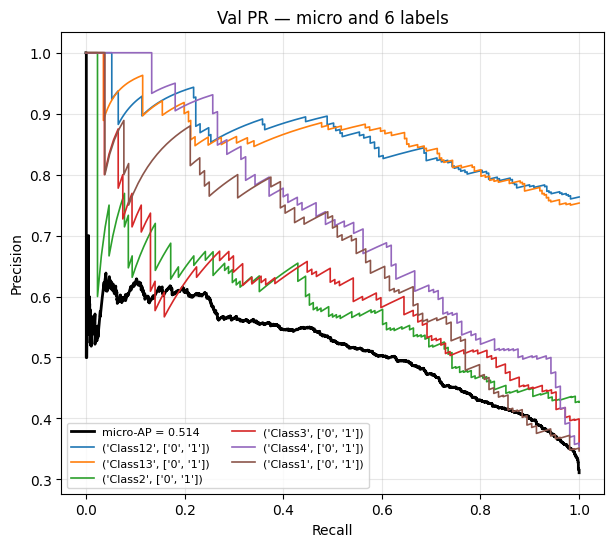

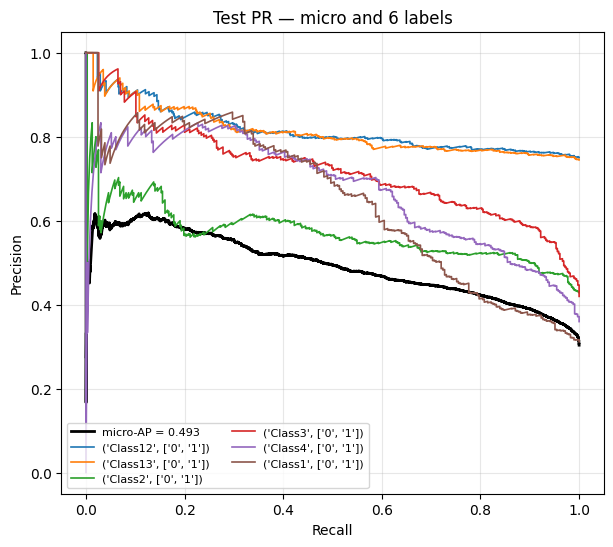

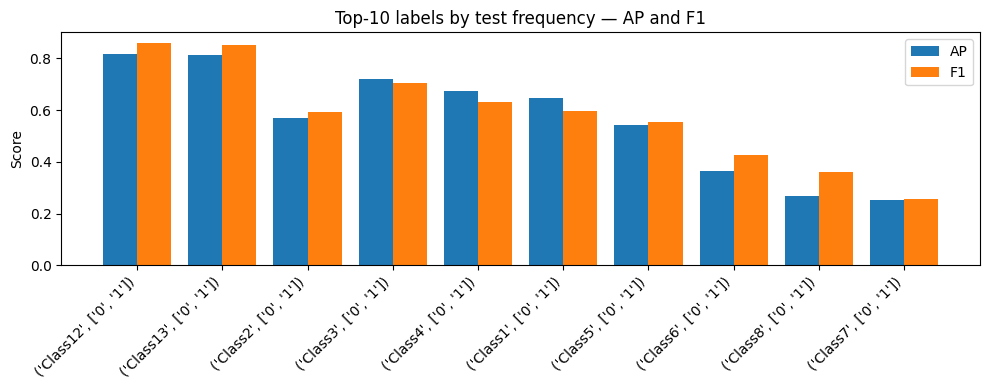

In [29]:
# Precision–Recall curves (micro + a few frequent labels)
from sklearn.metrics import precision_recall_curve

def plot_pr_curves(y_true, y_scores, label_names, k=6, mode="freq", title_prefix="Test"):
    ap_micro = average_precision_score(y_true, y_scores, average="micro")
    freq = y_true.sum(axis=0).astype(int)
    ap = np.array([average_precision_score(y_true[:, j], y_scores[:, j]) for j in range(y_true.shape[1])])

    if mode == "ap":
        idx = np.argsort(-ap)[:k]
    else:
        idx = np.argsort(-freq)[:k]
    names = [str(label_names[i]) for i in idx]

    plt.figure(figsize=(7, 6))
    p_micro, r_micro, _ = precision_recall_curve(y_true.ravel(), y_scores.ravel())
    plt.plot(r_micro, p_micro, color="black", lw=2, label=f"micro-AP = {ap_micro:.3f}")

    for i, name in zip(idx, names):
        p, r, _ = precision_recall_curve(y_true[:, i], y_scores[:, i])
        plt.plot(r, p, lw=1.2, label=f"{name}")

    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title(f"{title_prefix} PR — micro and {len(idx)} labels")
    plt.legend(loc="lower left", fontsize=8, ncol=2)
    plt.grid(True, alpha=0.3)
    plt.show()

plot_pr_curves(Y_val, Y_val_scores, label_names, k=6, mode="freq", title_prefix="Val")
plot_pr_curves(Y_te,  Y_te_scores,  label_names, k=6, mode="freq", title_prefix="Test")

# Per-label AP and F1 bar chart (top by frequency)
Y_te_pred = (Y_te_scores >= (t_perlabel if use_perlabel else t_global)).astype(int)
per_f1 = f1_score(Y_te, Y_te_pred, average=None, zero_division=0)
per_ap = np.array([average_precision_score(Y_te[:, j], Y_te_scores[:, j]) for j in range(Y_te.shape[1])])
freq = Y_te.sum(axis=0).astype(int)

idx = np.argsort(-freq)[:10]
names = [str(label_names[i]) for i in idx]
x = np.arange(len(idx)); w = 0.4
plt.figure(figsize=(10, 4))
plt.bar(x - w/2, per_ap[idx], width=w, label="AP")
plt.bar(x + w/2, per_f1[idx], width=w, label="F1")
plt.xticks(x, names, rotation=45, ha="right")
plt.ylabel("Score")
plt.title("Top-10 labels by test frequency — AP and F1")
plt.legend(); plt.tight_layout()
plt.show()